In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

save_path = "C:/D/ABHYAAS/OneDrive - Virginia Tech/naughtonlab - active_projects/2025-JIMSS_paper/SI_Figures/CV_Simulations"

inc_density = pd.read_csv('IncDensity_alpha1e-2.csv')
inc_density

,num_threads,spacing(mm),length(mm),force_mag(N),nonlinearity,memory,nonlinearity_cap,memory_cap
0,2,166.666667,500.0,0.0108,0.534861,0.165341,0.534861,0.165341
1,4,100.000000,500.0,0.0500,0.804757,0.375217,0.804757,0.375217
2,6,71.428571,500.0,0.1372,0.848598,0.409884,0.848598,0.409884
3,8,55.555556,500.0,0.2916,0.907641,0.570070,0.907641,0.570070
4,10,45.454545,500.0,0.5324,0.853333,0.514550,0.853333,0.514550
5,12,38.461538,500.0,0.8788,0.897216,0.242726,0.897216,0.242726


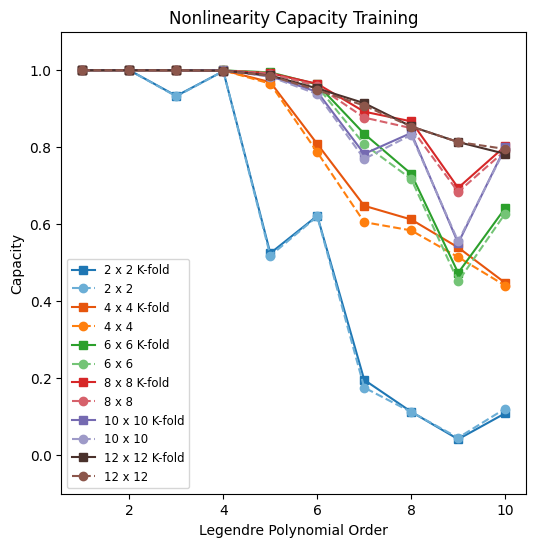

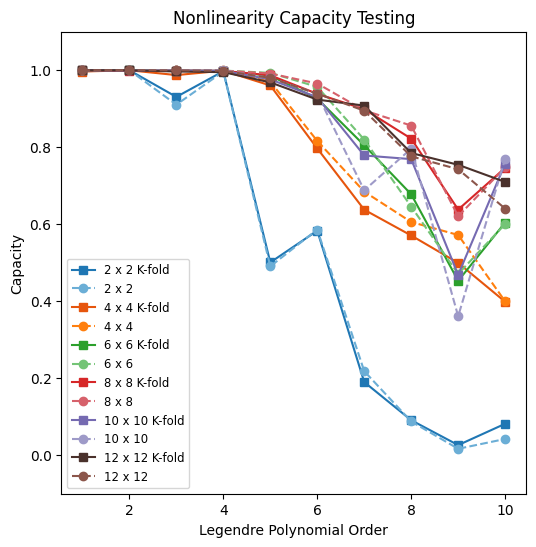

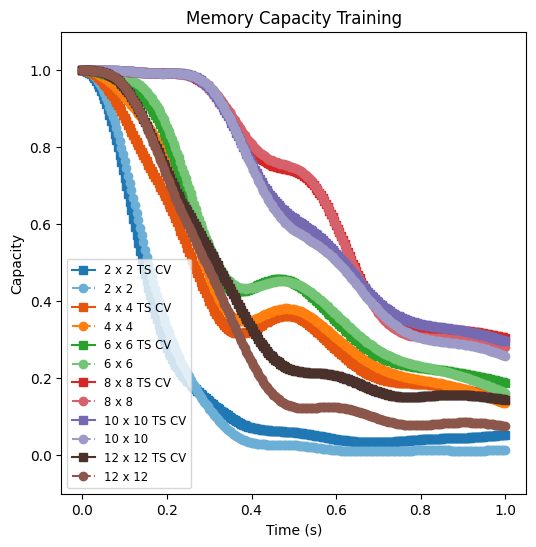

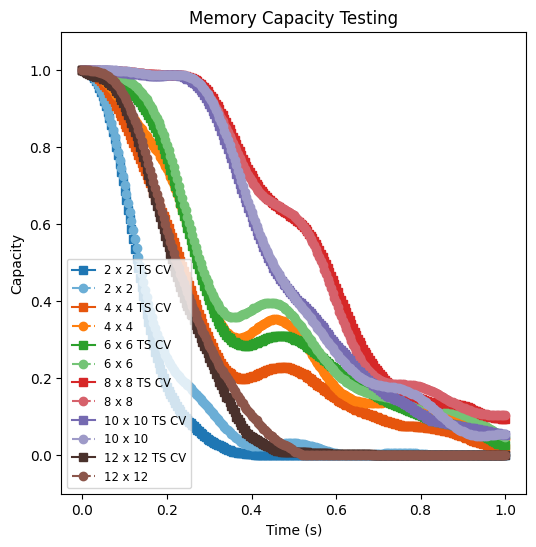

In [4]:
matplotlib.rc('pdf', fonttype=42)
num_threads = inc_density['num_threads'].values.tolist()

leg_x = np.linspace(1, 10, 10)
mem_x = np.linspace(0, 1, 251)

fig1, ax1 = plt.subplots(1, 1, figsize=(6, 6))
fig2, ax2 = plt.subplots(1, 1, figsize=(6, 6))
fig3, ax3 = plt.subplots(1, 1, figsize=(6, 6))
fig4, ax4 = plt.subplots(1, 1, figsize=(6, 6))
axs = [ax1, ax2, ax3, ax4]

# colors_list = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan']
# tab20_colors = list(plt.get_cmap('tab20').colors)
tab20_colors = ['#1f77b4', '#6baed6', '#e6550d', '#ff7f0e', '#2ca02c', '#74c476', 
                '#d62728', '#d6616b', '#756ab1', '#9e9ac8', '#4a312c', '#8c564b']

color_pairs = [
    (tab20_colors[(2 * i) % len(tab20_colors)], tab20_colors[(2 * i + 1) % len(tab20_colors)])
    for i in range(len(num_threads))
]

class PairColorSelector:
    def __init__(self, pairs, switch_after=4):
        self.pairs = pairs
        self.switch_after = switch_after
        self.call_count = {}

    def __getitem__(self, idx):
        n = self.call_count.get(idx, 0)
        self.call_count[idx] = n + 1
        return self.pairs[idx][0] if n < self.switch_after else self.pairs[idx][1]

colors_list = PairColorSelector(color_pairs, switch_after=4)

for i in range(len(num_threads)):

    data = np.load(f'{i}_eval_10fold.npz', allow_pickle=True)
    axs[0].plot(leg_x, data['nonlinearity'][0], '-s', color=colors_list[i], markersize=6, label=f'{num_threads[i]} x {num_threads[i]} K-fold')
    axs[1].plot(leg_x, data['nonlinearity'][1], '-s', color=colors_list[i], markersize=6, label=f'{num_threads[i]} x {num_threads[i]} K-fold')
    # axs[2].plot(mem_x, data['memory'][0], '-^', color=colors_list[i], label=f'{num_threads[i]} x {num_threads[i]} 10-fold', alpha=0.75)
    # axs[3].plot(mem_x, data['memory'][1], '-^', color=colors_list[i], label=f'{num_threads[i]} x {num_threads[i]} 10-fold', alpha=0.75)

    data = np.load(f'{i}_eval_10tscv.npz', allow_pickle=True)
    # axs[0].plot(leg_x, data['nonlinearity'][0], '-*', color=colors_list[i], label=f'{num_threads[i]} x {num_threads[i]} 10-tscv')
    # axs[1].plot(leg_x, data['nonlinearity'][1], '-*', color=colors_list[i], label=f'{num_threads[i]} x {num_threads[i]} 10-tscv')
    axs[2].plot(mem_x, data['memory'][0], '-s', color=colors_list[i], markersize=6, label=f'{num_threads[i]} x {num_threads[i]} TS CV')
    axs[3].plot(mem_x, data['memory'][1], '-s', color=colors_list[i], markersize=6, label=f'{num_threads[i]} x {num_threads[i]} TS CV')

    data = np.load(f'{i}_eval.npz', allow_pickle=True)
    # leg_cap = data['nonlinearity'][1]
    # mem_cap = data['memory'][1]
    # inc_density.at[i, 'nonlinearity_cap'] = sum(leg_cap)/len(leg_cap)
    # inc_density.at[i, 'memory_cap'] = sum(mem_cap)/len(mem_cap)
    # print(f"4th order: {leg_cap[3]}, 7th order: {leg_cap[6]}")
    # print(f"0.1s recall : {mem_cap[25]}, 0.4s recall: {mem_cap[100]}")
    # print("-------------------")
    axs[0].plot(leg_x, data['nonlinearity'][0], '--o', color=colors_list[i], label=f'{num_threads[i]} x {num_threads[i]}')
    axs[1].plot(leg_x, data['nonlinearity'][1], '--o', color=colors_list[i], label=f'{num_threads[i]} x {num_threads[i]}')
    axs[2].plot(mem_x, data['memory'][0], '--o', color=colors_list[i], label=f'{num_threads[i]} x {num_threads[i]}')
    axs[3].plot(mem_x, data['memory'][1], '--o', color=colors_list[i], label=f'{num_threads[i]} x {num_threads[i]}')
    
# inc_density.to_csv('IncDensity_alpha_1e-2.csv', index=False)

for ax in axs:
    ax.legend(loc='lower left', fontsize='small')
    ax.set_ylabel('Capacity')
    ax.set_ylim(-0.1, 1.1)
axs[0].set_title('Nonlinearity Capacity Training')
axs[1].set_title('Nonlinearity Capacity Testing')
axs[2].set_title('Memory Capacity Training')
axs[3].set_title('Memory Capacity Testing')
axs[0].set_xlabel('Legendre Polynomial Order')
axs[1].set_xlabel('Legendre Polynomial Order')
axs[2].set_xlabel('Time (s)')
axs[3].set_xlabel('Time (s)')

# plt.show()

fig1.savefig(f'{save_path}/K_fold_Increasing_Density_Crosshatch_Nonlinearity_Training.pdf', dpi=300)
fig2.savefig(f'{save_path}/K_fold_Increasing_Density_Crosshatch_Nonlinearity_Testing.pdf', dpi=300)
fig3.savefig(f'{save_path}/TSCV_Increasing_Density_Crosshatch_Memory_Training.pdf', dpi=300)
fig4.savefig(f'{save_path}/TSCV_Increasing_Density_Crosshatch_Memory_Testing.pdf', dpi=300)

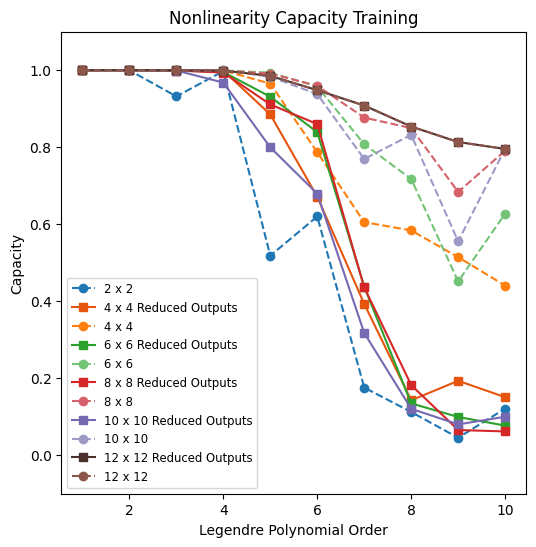

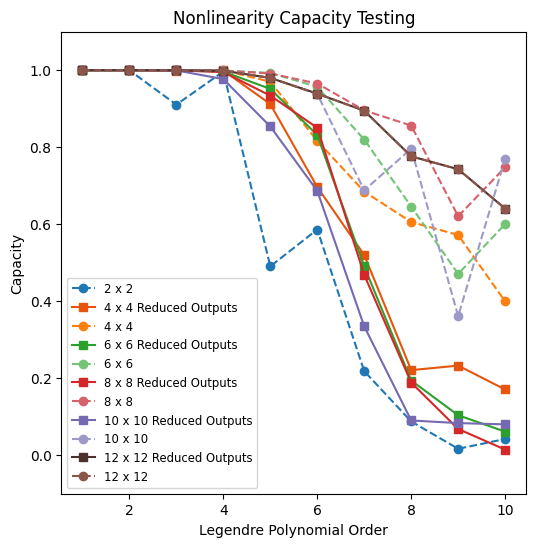

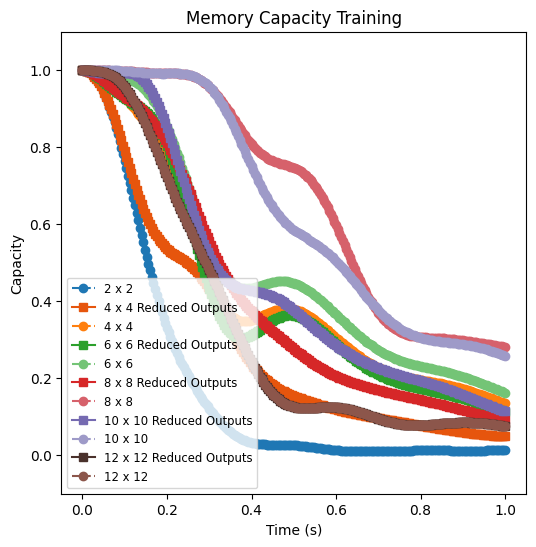

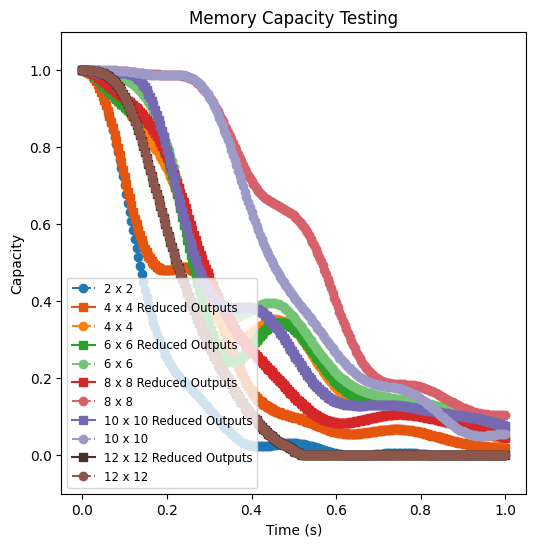

In [ ]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

save_path = "C:/D/ABHYAAS/OneDrive - Virginia Tech/naughtonlab - active_projects/2025-JIMSS_paper/SI_Figures/Increased_Outputs"

matplotlib.rc('pdf', fonttype=42)
num_threads = [2, 4, 6, 8, 10, 12]

leg_x = np.linspace(1, 10, 10)
mem_x = np.linspace(0, 1, 251)

fig1, ax1 = plt.subplots(1, 1, figsize=(6, 6))
fig2, ax2 = plt.subplots(1, 1, figsize=(6, 6))
fig3, ax3 = plt.subplots(1, 1, figsize=(6, 6))
fig4, ax4 = plt.subplots(1, 1, figsize=(6, 6))
axs = [ax1, ax2, ax3, ax4]

# # colors_list = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan']
# # tab20_colors = list(plt.get_cmap('tab20').colors)
tab20_colors = ['#1f77b4', '#6baed6', '#e6550d', '#ff7f0e', '#2ca02c', '#74c476', 
                '#d62728', '#d6616b', '#756ab1', '#9e9ac8', '#4a312c', '#8c564b']

color_pairs = [
    (tab20_colors[(2 * i) % len(tab20_colors)], tab20_colors[(2 * i + 1) % len(tab20_colors)])
    for i in range(len(num_threads))
]

class PairColorSelector:
    def __init__(self, pairs, switch_after=4):
        self.pairs = pairs
        self.switch_after = switch_after
        self.call_count = {}

    def __getitem__(self, idx):
        n = self.call_count.get(idx, 0)
        self.call_count[idx] = n + 1
        return self.pairs[idx][0] if n < self.switch_after else self.pairs[idx][1]

colors_list = PairColorSelector(color_pairs, switch_after=4)

for i in range(len(num_threads)):

    if i != 0:
        data_reduced = np.load(f'{i}_eval_reduced_op.npz', allow_pickle=True)
    
        axs[0].plot(leg_x, data_reduced['nonlinearity'][0], '-s', color=colors_list[i], markersize=6, label=f'{num_threads[i]} x {num_threads[i]} Reduced Outputs')
        axs[1].plot(leg_x, data_reduced['nonlinearity'][1], '-s', color=colors_list[i], markersize=6, label=f'{num_threads[i]} x {num_threads[i]} Reduced Outputs')
        axs[2].plot(mem_x, data_reduced['memory'][0], '-s', color=colors_list[i], markersize=6, label=f'{num_threads[i]} x {num_threads[i]} Reduced Outputs')
        axs[3].plot(mem_x, data_reduced['memory'][1], '-s', color=colors_list[i], markersize=6, label=f'{num_threads[i]} x {num_threads[i]} Reduced Outputs')
    else:
        data = np.load(f'{i}_eval.npz', allow_pickle=True)
    # leg_cap = data['nonlinearity'][1]
    # mem_cap = data['memory'][1]
    # inc_density.at[i, 'nonlinearity_cap'] = sum(leg_cap)/len(leg_cap)
    # inc_density.at[i, 'memory_cap'] = sum(mem_cap)/len(mem_cap)
    # print(f"4th order: {leg_cap[3]}, 7th order: {leg_cap[6]}")
    # print(f"0.1s recall : {mem_cap[25]}, 0.4s recall: {mem_cap[100]}")
    # print("-------------------")
    axs[0].plot(leg_x, data['nonlinearity'][0], '--o', color=colors_list[i], label=f'{num_threads[i]} x {num_threads[i]}')
    axs[1].plot(leg_x, data['nonlinearity'][1], '--o', color=colors_list[i], label=f'{num_threads[i]} x {num_threads[i]}')
    axs[2].plot(mem_x, data['memory'][0], '--o', color=colors_list[i], label=f'{num_threads[i]} x {num_threads[i]}')
    axs[3].plot(mem_x, data['memory'][1], '--o', color=colors_list[i], label=f'{num_threads[i]} x {num_threads[i]}')
    
# inc_density.to_csv('IncDensity_alpha_1e-2.csv', index=False)

for ax in axs:
    ax.legend(loc='lower left', fontsize='small')
    ax.set_ylabel('Capacity')
    ax.set_ylim(-0.1, 1.1)
axs[0].set_title('Nonlinearity Capacity Training')
axs[1].set_title('Nonlinearity Capacity Testing')
axs[2].set_title('Memory Capacity Training')
axs[3].set_title('Memory Capacity Testing')
axs[0].set_xlabel('Legendre Polynomial Order')
axs[1].set_xlabel('Legendre Polynomial Order')
axs[2].set_xlabel('Time (s)')
axs[3].set_xlabel('Time (s)')

plt.show()

# fig1.savefig(f'{save_path}/K_fold_Increasing_Density_Crosshatch_Nonlinearity_Training.pdf', dpi=300)
# fig2.savefig(f'{save_path}/K_fold_Increasing_Density_Crosshatch_Nonlinearity_Testing.pdf', dpi=300)
# fig3.savefig(f'{save_path}/TSCV_Increasing_Density_Crosshatch_Memory_Training.pdf', dpi=300)
# fig4.savefig(f'{save_path}/TSCV_Increasing_Density_Crosshatch_Memory_Testing.pdf', dpi=300)

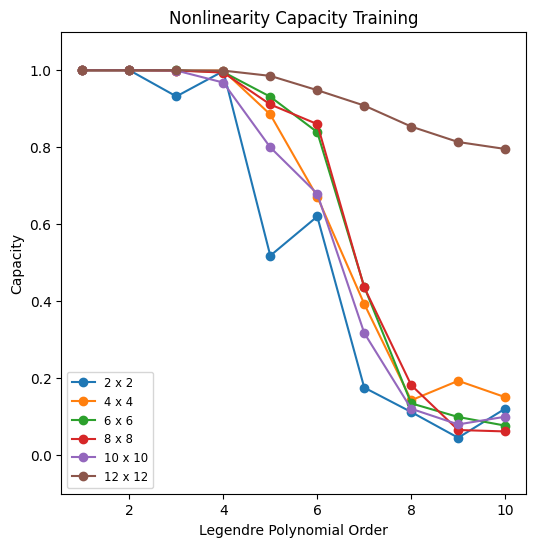

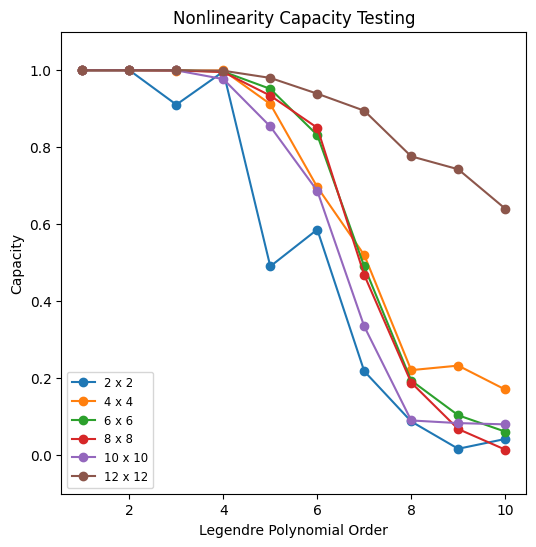

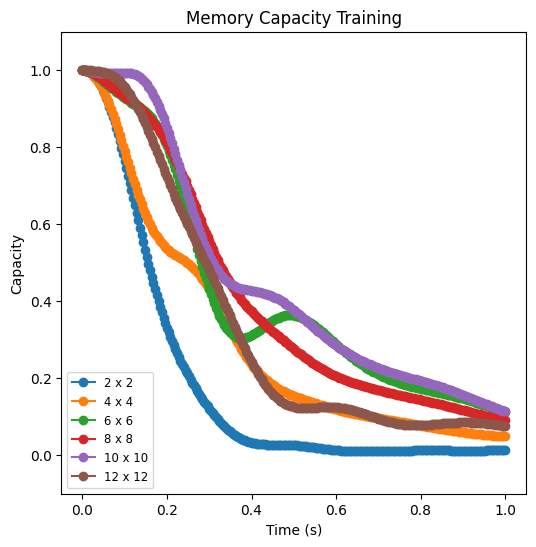

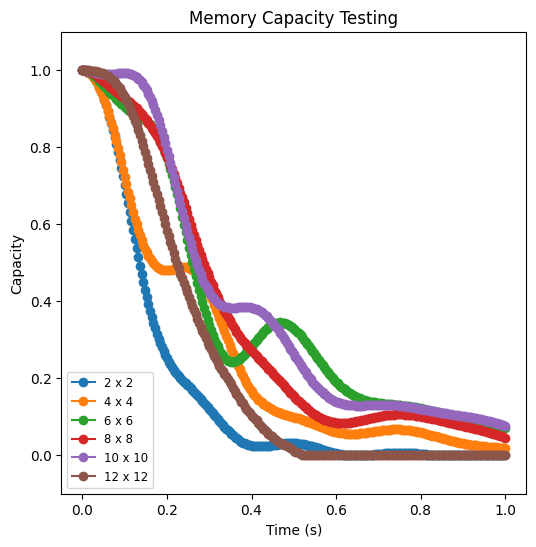

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

save_path = "C:/D/ABHYAAS/OneDrive - Virginia Tech/naughtonlab - active_projects/2025-JIMSS_paper/SI_Figures/Increased_Outputs"

matplotlib.rc('pdf', fonttype=42)
num_threads = [2, 4, 6, 8, 10, 12]

leg_x = np.linspace(1, 10, 10)
mem_x = np.linspace(0, 1, 251)

fig1, ax1 = plt.subplots(1, 1, figsize=(6, 6))
fig2, ax2 = plt.subplots(1, 1, figsize=(6, 6))
fig3, ax3 = plt.subplots(1, 1, figsize=(6, 6))
fig4, ax4 = plt.subplots(1, 1, figsize=(6, 6))
axs = [ax1, ax2, ax3, ax4]

for i in range(len(num_threads)):

    if i != 0:
        data = np.load(f'{i}_eval_reduced_op.npz', allow_pickle=True)
    else:
        data = np.load(f'{i}_eval.npz', allow_pickle=True)

    axs[0].plot(leg_x, data['nonlinearity'][0], '-o', label=f'{num_threads[i]} x {num_threads[i]}')
    axs[1].plot(leg_x, data['nonlinearity'][1], '-o', label=f'{num_threads[i]} x {num_threads[i]}')
    axs[2].plot(mem_x, data['memory'][0], '-o', label=f'{num_threads[i]} x {num_threads[i]}')
    axs[3].plot(mem_x, data['memory'][1], '-o', label=f'{num_threads[i]} x {num_threads[i]}')    

    # leg_cap = data['nonlinearity'][1]
    # mem_cap = data['memory'][1]
    # inc_density.at[i, 'nonlinearity_cap'] = sum(leg_cap)/len(leg_cap)
    # inc_density.at[i, 'memory_cap'] = sum(mem_cap)/len(mem_cap)
    # print(f"4th order: {leg_cap[3]}, 7th order: {leg_cap[6]}")
    # print(f"0.1s recall : {mem_cap[25]}, 0.4s recall: {mem_cap[100]}")
    # print("-------------------")
    
    
# inc_density.to_csv('IncDensity_alpha_1e-2.csv', index=False)

for ax in axs:
    ax.legend(loc='lower left', fontsize='small')
    ax.set_ylabel('Capacity')
    ax.set_ylim(-0.1, 1.1)
axs[0].set_title('Nonlinearity Capacity Training')
axs[1].set_title('Nonlinearity Capacity Testing')
axs[2].set_title('Memory Capacity Training')
axs[3].set_title('Memory Capacity Testing')
axs[0].set_xlabel('Legendre Polynomial Order')
axs[1].set_xlabel('Legendre Polynomial Order')
axs[2].set_xlabel('Time (s)')
axs[3].set_xlabel('Time (s)')

plt.show()

fig1.savefig(f'{save_path}/Reduced_Outputs_Increasing_Density_Crosshatch_Nonlinearity_Training.pdf', dpi=300)
fig2.savefig(f'{save_path}/Reduced_Outputs_Increasing_Density_Crosshatch_Nonlinearity_Testing.pdf', dpi=300)
fig3.savefig(f'{save_path}/Reduced_Outputs_Increasing_Density_Crosshatch_Memory_Training.pdf', dpi=300)
fig4.savefig(f'{save_path}/Reduced_Outputs_Increasing_Density_Crosshatch_Memory_Testing.pdf', dpi=300)

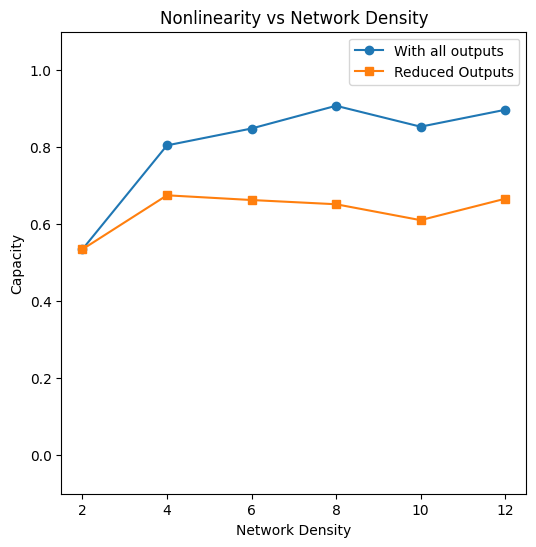

In [2]:
inc_density_reduced_op = pd.read_csv('IncDensity_reduced_op.csv')
fig5, ax5 = plt.subplots(1, 1, figsize=(6, 6))
ax5.plot(inc_density_reduced_op['num_threads'], inc_density_reduced_op['nonlinearity'], '-o', label='With all outputs')
ax5.plot(inc_density_reduced_op['num_threads'], inc_density_reduced_op['nonlinearity_red_op'], '-s', label='Reduced Outputs')
ax5.set_xlabel('Network Density')
ax5.set_ylabel('Capacity')
ax5.set_title('Nonlinearity vs Network Density')
ax5.set_ylim(-0.1, 1.1)
ax5.legend()
fig5.savefig(f'{save_path}/Reduced_Outputs_Increasing_Density_Crosshatch_Nonlinearity_vs_Density.pdf', dpi=300)
plt.show()


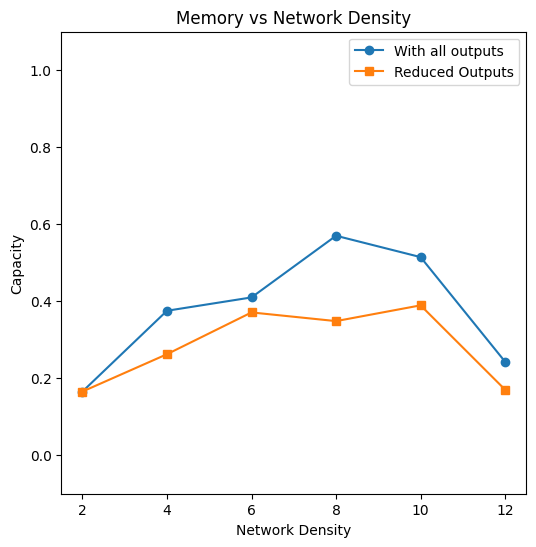

In [3]:
fig6, ax6 = plt.subplots(1, 1, figsize=(6, 6))
ax6.plot(inc_density_reduced_op['num_threads'], inc_density_reduced_op['memory'], '-o', label='With all outputs')
ax6.plot(inc_density_reduced_op['num_threads'], inc_density_reduced_op['memory_red_op'], '-s', label='Reduced Outputs')
ax6.set_xlabel('Network Density')
ax6.set_ylabel('Capacity')
ax6.set_title('Memory vs Network Density')
ax6.set_ylim(-0.1, 1.1)
ax6.legend()
fig6.savefig(f'{save_path}/Reduced_Outputs_Increasing_Density_Crosshatch_Memory_vs_Density.pdf', dpi=300)
plt.show()

In [4]:
inc_density_reduced_op['nonlinearity_op_contri'] = inc_density_reduced_op['nonlinearity'] - inc_density_reduced_op['nonlinearity_red_op']
inc_density_reduced_op['memory_op_contri'] = inc_density_reduced_op['memory'] - inc_density_reduced_op['memory_red_op']
inc_density_reduced_op['nonlinearity_op_contri_percent'] = (inc_density_reduced_op['nonlinearity_op_contri'] / inc_density_reduced_op['nonlinearity_red_op']) * 100
inc_density_reduced_op['memory_op_contri_percent'] = (inc_density_reduced_op['memory_op_contri'] / inc_density_reduced_op['memory_red_op']) * 100
inc_density_reduced_op.to_csv('IncDensity_reduced_op_contribution.csv', index=False)
inc_density_reduced_op

,num_threads,nonlinearity,memory,nonlinearity_red_op,memory_red_op,nonlinearity_op_contri,memory_op_contri,nonlinearity_op_contri_percent,memory_op_contri_percent
0,2,0.534861,0.165341,0.534861,0.165341,0.000000,0.000000,0.000000,0.000000
1,4,0.804757,0.375217,0.675105,0.262376,0.129653,0.112841,19.204802,43.007540
2,6,0.848598,0.409884,0.662858,0.370908,0.185740,0.038976,28.021069,10.508226
3,8,0.907641,0.570070,0.651875,0.348351,0.255765,0.221719,39.235330,63.648002
4,10,0.853333,0.514550,0.610557,0.389295,0.242775,0.125255,39.762927,32.174934
5,12,0.897216,0.242726,0.666193,0.170109,0.231023,0.072617,34.678047,42.688493


In [5]:
inc_density_reduced_op['nonlinearity_op_contri_percent'].mean()

26.81702907148392

In [6]:
inc_density_reduced_op['memory_op_contri_percent'].mean()

32.00453232721095

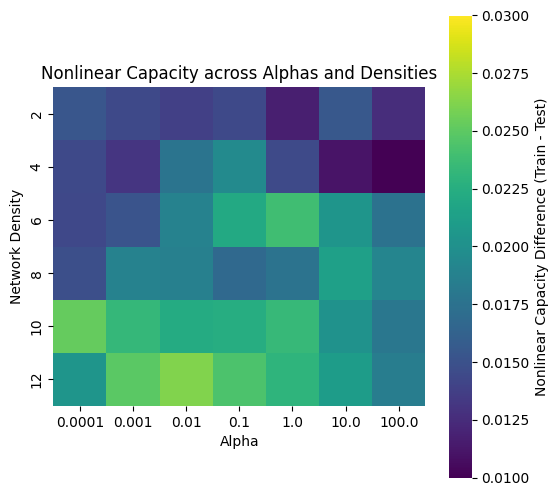

In [5]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

save_path = "C:/D/ABHYAAS/OneDrive - Virginia Tech/naughtonlab - active_projects/2025-JIMSS_paper/SI_Figures/CV_Simulations"

inc_density_alphaCV = pd.read_csv('IncDensity_10_alphaCV.csv')
inc_density_alphaCV['nonlinear_diff'] = inc_density_alphaCV['nonlinearity train'] - inc_density_alphaCV['nonlinearity test']
inc_density_alphaCV['memory_diff'] = inc_density_alphaCV['memory train'] - inc_density_alphaCV['memory test']

fig7, ax7 = plt.subplots(1, 1, figsize=(6, 6))
heatmap_data = inc_density_alphaCV.pivot(index='num_threads', columns='alpha', values='nonlinear_diff')
sns.heatmap(heatmap_data, annot=False, cmap='viridis', cbar_kws={'label': 'Nonlinear Capacity Difference (Train - Test)'}, ax=ax7, vmin=np.round(heatmap_data.min().min(), 2), vmax=np.round(heatmap_data.max().max(), 2), square=True)
ax7.set_xlabel('Alpha')
ax7.set_ylabel('Network Density')
ax7.set_title('Nonlinear Capacity across Alphas and Densities')
fig7.savefig(f'{save_path}/Nonlinear_Capacity_Heatmap_Alphas_Densities.pdf', dpi=300)
plt.show()

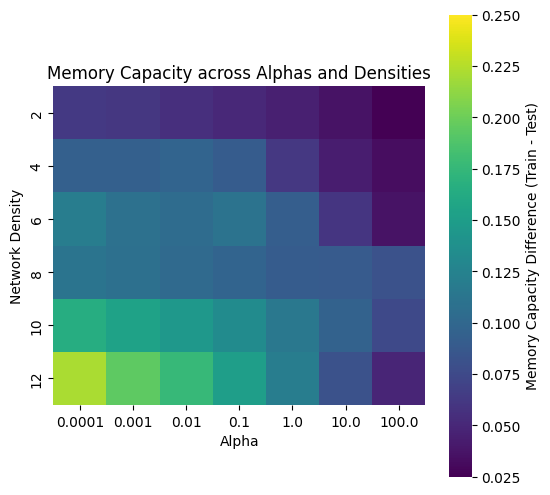

In [8]:
fig8, ax8 = plt.subplots(1, 1, figsize=(6, 6))
heatmap_data = inc_density_alphaCV.pivot(index='num_threads', columns='alpha', values='memory_diff')
sns.heatmap(heatmap_data, annot=False, cmap='viridis', cbar_kws={'label': 'Memory Capacity Difference (Train - Test)'}, ax=ax8, vmin=0.025, vmax=0.25, square=True)
ax8.set_xlabel('Alpha')
ax8.set_ylabel('Network Density')
ax8.set_title('Memory Capacity across Alphas and Densities')
fig8.savefig(f'{save_path}/Memory_Capacity_Heatmap_Alphas_Densities.pdf', dpi=300)
plt.show()

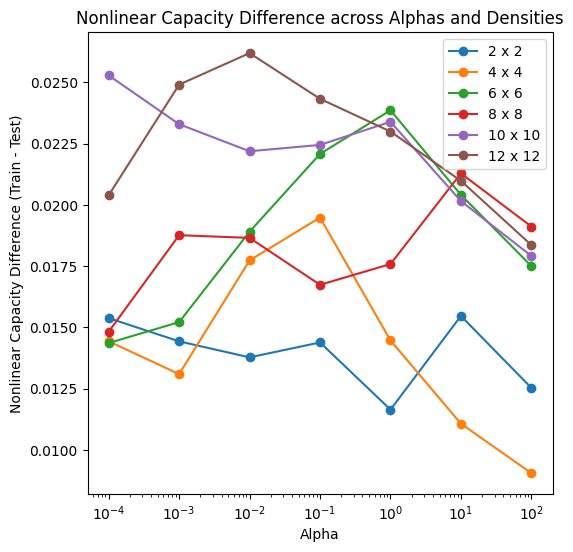

In [15]:
fig9, ax9 = plt.subplots(1, 1, figsize=(6, 6))
for num_threads in inc_density_alphaCV['num_threads'].unique():
    subset = inc_density_alphaCV[inc_density_alphaCV['num_threads'] == num_threads]
    ax9.plot(subset['alpha'], subset['nonlinear_diff'], '-o', label=f'{num_threads} x {num_threads}')
    plt.semilogx()
ax9.set_xlabel('Alpha')
ax9.set_ylabel('Nonlinear Capacity Difference (Train - Test)')
ax9.set_title('Nonlinear Capacity Difference across Alphas and Densities')
ax9.legend()
plt.show()

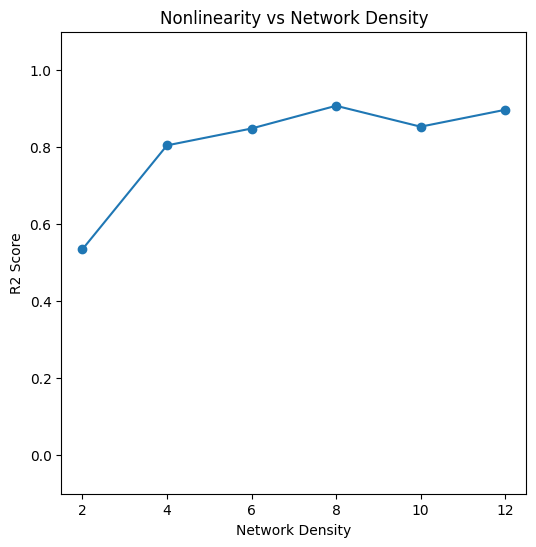

In [9]:
fig5, ax5 = plt.subplots(1, 1, figsize=(6, 6))
ax5.plot(num_threads, inc_density['nonlinearity_cap'], '-o')
ax5.set_xlabel('Network Density')
ax5.set_ylabel('R2 Score')
ax5.set_title('Nonlinearity vs Network Density')
ax5.set_ylim(-0.1, 1.1)
fig5.savefig(f'{save_path}/Increasing_Density_Crosshatch_Nonlinearity_vs_Density.pdf', dpi=300)


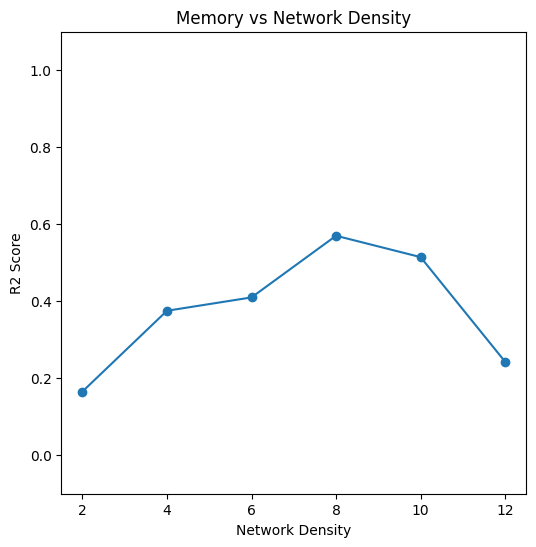

In [10]:
fig6, ax6 = plt.subplots(1, 1, figsize=(6, 6))
ax6.plot(num_threads, inc_density['memory_cap'], '-o')
ax6.set_xlabel('Network Density')
ax6.set_ylabel('R2 Score')
ax6.set_title('Memory vs Network Density')
ax6.set_ylim(-0.1, 1.1)
fig6.savefig(f'{save_path}/Increasing_Density_Crosshatch_Memory_vs_Density.pdf', dpi=300)

In [7]:
matplotlib.rc('pdf', fonttype=42)
data = np.load('3_eval.npz', allow_pickle=True)

In [3]:
from scipy.special import legendre
from scipy.interpolate import CubicSpline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

def nonlinearity_testing(input_sig, output, leg_max_order, regressor, test_size, alpha):
    if regressor == "Lin":
        ### Linear Regression
        clf = LinearRegression()
    elif regressor == "Rid":
        ### Ridge Regression
        clf = Ridge(alpha=alpha)
    else:
        print("Please specify the regressor")

    x = output
    capacity_train_list = []
    capacity_test_list = []
    R2_train_list = []
    R2_test_list = []
    for n in range(1, leg_max_order+1):
        leg = legendre(n)
        y = leg(input_sig)
        shape_input = input_sig.shape
        train_size = int(shape_input[0] * (1 - test_size))
        y2 = (1/len(y)) * np.sum((y-np.mean(y))**2)

        x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=test_size, random_state=42, shuffle=False)

        # Training
        clf.fit(x_train, y_train)
        y_train_pred = clf.predict(x_train)
        
        idx = np.where(abs(y_train_pred) > 1)
        y_train_pred[idx] = np.mean(y)
        y_train[idx, 0] = np.mean(y)
        
        y2_train = (1/len(y_train)) * np.sum((y_train-np.mean(y_train))**2)

        MSE = mean_squared_error(y_true=y_train, y_pred=y_train_pred)
        capacity_train = 1 - MSE/y2_train
        R2_train = r2_score(y_true=y_train, y_pred=y_train_pred)

        # Testing
        y_test_pred = clf.predict(x_test)

        idx = np.where(abs(y_test_pred) > 1)
        y_test_pred[idx] = np.mean(y)
        y_test[idx, 0] = np.mean(y)

        y2_test = (1/len(y_test)) * np.sum((y_test-np.mean(y_test))**2)

        MSE = mean_squared_error(y_true=y_test, y_pred=y_test_pred)
        capacity_test = 1 - MSE/y2_test
        R2_test = r2_score(y_true=y_test, y_pred=y_test_pred)

        if R2_test < 0:
            R2_test = 0
        if R2_train < 0:
            R2_train = 0
        if capacity_test < 0:
            capacity_test = 0
        if capacity_train < 0:
            capacity_train = 0

        # print("legendre", n, "MSE", MSE_train, MSE_test, "y2", y2, "capacity", capacity_train, capacity_test)

        pred = np.concatenate((y_train_pred, y_test_pred), axis=0)

        plt.figure(figsize=(7.5, 7.5))
        x_axis = np.linspace(-1, 1, y.shape[0])
        plt.scatter(input_sig, pred, s=10, color='tab:orange', label='Predicted', zorder=0)
        plt.plot(x_axis, leg(x_axis), color='k', label='True')
        plt.title(f'Legendre Polynomial Order: {n}')
        plt.legend()
        plt.ylim(-1.25, 1.25)
        plt.savefig(f'{save_path}/8x8_legendre/leg_{n}.pdf', dpi=300) 
        plt.close()   

        capacity_train_list.append(capacity_train)
        capacity_test_list.append(capacity_test)
        R2_train_list.append(R2_train)
        R2_test_list.append(R2_test)

    return capacity_train_list, capacity_test_list, R2_train_list, R2_test_list

def memory_testing(input_sig, output, max_timesteps_back, regressor, test_size, alpha):
    if regressor == "Lin":
        ### Linear Regression
        clf = LinearRegression()
    elif regressor == "Rid":
        ### Ridge Regression
        clf = Ridge(alpha=alpha)
    else:
        print("Please specify the regressor")

    capacity_train_list = []
    capacity_test_list = []
    R2_train_list = []
    R2_test_list = []
    for n in range(0, max_timesteps_back+1):
        x = output[n:]
        if n == 0:
            y = input_sig
        else:
            y = input_sig[:-n]

        y2 = (1/len(y)) * np.sum((y-np.mean(y))**2)
        x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=test_size, random_state=42, shuffle=False)

        # Training
        clf.fit(x_train, y_train)
        y_train_pred = clf.predict(x_train)
        
        idx = np.where(abs(y_train_pred) > 1)
        y_train_pred[idx] = np.mean(y)
        y_train[idx, 0] = np.mean(y)
        
        y2_train = (1/len(y_train)) * np.sum((y_train-np.mean(y_train))**2)

        MSE = mean_squared_error(y_true=y_train, y_pred=y_train_pred)
        capacity_train = 1 - MSE/y2_train
        R2_train = r2_score(y_true=y_train, y_pred=y_train_pred)

        # Testing
        y_test_pred = clf.predict(x_test)

        idx = np.where(abs(y_test_pred) > 1)
        y_test_pred[idx] = np.mean(y)
        y_test[idx, 0] = np.mean(y)

        y2_test = (1/len(y_test)) * np.sum((y_test-np.mean(y_test))**2)

        MSE = mean_squared_error(y_true=y_test, y_pred=y_test_pred)
        capacity_test = 1 - MSE/y2_test
        R2_test = r2_score(y_true=y_test, y_pred=y_test_pred)

        if R2_test < 0:
            R2_test = 0
        if R2_train < 0:
            R2_train = 0
        if capacity_test < 0:
            capacity_test = 0
        if capacity_train < 0:
            capacity_train = 0

        n_sec = n/250
        if n%25 == 0 and n_sec <= 1.0:
            num_steps = int(250*20)
            time_axis = np.linspace(0, len(y_test)/250, len(y_test))
            plt.figure(figsize=(4*7.5, 7.5))
            plt.plot(time_axis, input_sig[-1-len(y_test):-1], '-', lw=4, label=f'Actual input at {n_sec}')
            plt.plot(time_axis, y_test, '-', lw=2.5, label='Target')
            plt.plot(time_axis, y_test_pred, '-', lw=1, label='Predicted')
            plt.title(f'Recall Time {n_sec} s')
            plt.ylim(-1.25, 1.25)
            plt.legend()
            plt.savefig(f'{save_path}/8x8_memory/mem_{n_sec}.pdf', dpi=300)    
            plt.close()

        capacity_train_list.append(capacity_train)
        capacity_test_list.append(capacity_test)
        R2_train_list.append(R2_train)
        R2_test_list.append(R2_test)

        # print("memory", n, R2_train, R2_test, capacity_train, capacity_test)

    return capacity_train_list, capacity_test_list, R2_train_list, R2_test_list

In [4]:
input_data = data['input_data']
output_data = data['output_data']
regressor = "Rid"
test_size = 0.25
alpha = 1e-2
fps = 250 

leg_max_order = 10
max_time_back_seconds = 1
max_timesteps_back = np.rint(fps*max_time_back_seconds).astype(int)

# Nonlinearity testing
# leg_capacity_train_list, leg_capacity_test_list, leg_R2_train_list, leg_R2_test_list = nonlinearity_testing(input_data, output_data, leg_max_order, regressor, test_size, alpha)

# Memory testing
mem_capacity_train_list, mem_capacity_test_list, mem_R2_train_list, mem_R2_test_list = memory_testing(input_data, output_data, max_timesteps_back, regressor, test_size, alpha)